# SHINE_SWE_OPENSOURCE Dataset Analysis

This notebook provides comprehensive analysis of the SHINE_SWE_OPENSOURCE dataset:
1. **Repo Statistics**: Number of repos per dataset, trajectories per repo, correctness breakdown
2. **Token Length Distribution**: Using Qwen3.6-27B tokenizer with parallel processing
   - Per dataset / per repo / per role (system, user, assistant)
   - Summary tables with mean, max, min

In [1]:
import json
import os
import sys
import time
from pathlib import Path
from collections import Counter, defaultdict
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
from multiprocessing import cpu_count
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['figure.figsize'] = (14, 6)
matplotlib.rcParams['figure.dpi'] = 100

DATA_DIR = Path('../data/SHINE_SWE_OPENSOURCE')
MODEL_DIR = '../models/Qwen3.6-27B'

jsonl_files = sorted(DATA_DIR.glob('*.openai.jsonl'))
print(f'Data directory: {DATA_DIR}')
print(f'Number of JSONL files: {len(jsonl_files)}')
for f in jsonl_files:
    size = f.stat().st_size
    size_str = f'{size/1e9:.2f} GB' if size > 1e9 else f'{size/1e6:.2f} MB'
    print(f'  {f.name:<75} {size_str}')

Data directory: ../data/SHINE_SWE_OPENSOURCE
Number of JSONL files: 10
  CoderForge-Preview.openai.jsonl                                             91.08 GB
  Kwai-Klear-SWE-smith-mini-swe-agent-plus-trajectories-66k.openai.jsonl      4.91 GB
  Nemotron-SWE-v1.openai.jsonl                                                11.16 GB
  SWE-Gym-OpenHands-SFT-Trajectories.openai.jsonl                             33.54 MB
  SWE-Hero-openhands-trajectories.openai.jsonl                                7.76 GB
  SWE-Lego-Real-Data.openai.jsonl                                             4.57 GB
  SWE-Lego-Synthetic-Data.openai.jsonl                                        2.17 GB
  SWE-Zero-openhands-trajectories.openai.jsonl                                35.76 GB
  SWE-rebench-openhands-trajectories.openai.jsonl                             18.23 GB
  SWE-smith-trajectories.openai.jsonl                                         10.93 GB


## 1. Load Tokenizer (Qwen3.6-27B)

In [2]:
from transformers import AutoTokenizer

print(f'Loading tokenizer from: {MODEL_DIR}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, trust_remote_code=True)
print(f'Tokenizer loaded: vocab_size={tokenizer.vocab_size}')
print(f'Tokenizer type: {type(tokenizer).__name__}')

/opt/conda/envs/torch-base/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/conda/envs/torch-base/lib/python3.13/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Loading tokenizer from: ../models/Qwen3.6-27B
Tokenizer loaded: vocab_size=248044
Tokenizer type: TokenizersBackend


## 2. Parallel Data Loading & Tokenization

We load all data and tokenize each message in parallel for efficiency.
Each sample's metadata (source_dataset, repo, correctness) and per-message token lengths are extracted.

In [ ]:
import threading
import pickle
import queue
import struct

# ============================================================
# Checkpoint/Resume Infrastructure
# ============================================================
# Strategy: For each JSONL file, we maintain a checkpoint JSONL file
# that stores processed results line-by-line. The line number in the
# checkpoint corresponds to the line number in the source file.
# On resume, we count how many lines are already in the checkpoint
# and skip that many lines from the source file.
#
# Within a single file, we use multiple worker threads to tokenize
# in parallel (one reader thread feeds lines to N tokenizer workers).
# Results are written to checkpoint in order (using a sorted buffer).
# ============================================================

CHECKPOINT_DIR = Path('.') / 'cache' / 'checkpoints_opensource'
CHECKPOINT_DIR.mkdir(exist_ok=True)

# Number of tokenizer worker threads PER FILE
NUM_TOKENIZE_WORKERS = min(64, cpu_count())
# How often to flush checkpoint to disk (every N samples)
CHECKPOINT_FLUSH_INTERVAL = 100

_print_lock = threading.Lock()

def get_checkpoint_path(filepath, max_samples=None):
    """Get checkpoint file path for a given source file."""
    safe_name = filepath.stem.replace('.openai', '')
    suffix = '' if max_samples is None else f'_max{max_samples}'
    return CHECKPOINT_DIR / f'{safe_name}{suffix}.ckpt.jsonl'

def count_checkpoint_lines(ckpt_path):
    """Count how many lines (processed samples) are in the checkpoint file."""
    if not ckpt_path.exists():
        return 0
    count = 0
    with open(ckpt_path, 'rb') as f:
        for _ in f:
            count += 1
    return count

def load_checkpoint_results(ckpt_path):
    """Load all results from a checkpoint file."""
    results = []
    if not ckpt_path.exists():
        return results
    with open(ckpt_path, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                results.append(json.loads(line))
            except Exception:
                break  # Stop at first corrupted line
    return results

import re

def extract_repo_from_metadata(d):
    """Extract repo name from various metadata fields when 'repo' is null.
    
    Strategies:
    1. CoderForge-Preview: trajectory_id format '{prefix}_{repo}_final_{hash}_run{N}'
       e.g. 'qingyangwu_aiohttp_final_006fbe03..._run1' -> 'aiohttp'
    2. SWE-smith / Kwai-Klear: instance_id format '{owner}__{repo}.{hash}.{suffix}'
       e.g. 'mahmoud__boltons.3bfcfdd0.lm_rewrite__or...' -> 'mahmoud/boltons'
    3. SWE-Gym-OpenHands: no reliable field, return 'unknown'
    """
    # Try trajectory_id first (CoderForge-Preview)
    trajectory_id = d.get('trajectory_id')
    if trajectory_id:
        # Format: {prefix}_{repo}_final_{hash}_run{N}
        m = re.match(r'^[^_]+_(.+?)_final_[0-9a-f]+_run\d+$', trajectory_id)
        if m:
            return m.group(1)
    
    # Try instance_id (SWE-smith, Kwai-Klear)
    instance_id = d.get('instance_id')
    if instance_id:
        # Format: {owner}__{repo}.{hash}.{suffix}
        m = re.match(r'^([^_]+)__([^.]+)\.', instance_id)
        if m:
            return f"{m.group(1)}/{m.group(2)}"
    
    return 'unknown'

def tokenize_worker(encode_fn, in_queue, out_dict, out_lock, fallback_source):
    """Worker thread: takes (line_idx, line) from queue, tokenizes, puts result in out_dict."""
    while True:
        item = in_queue.get()
        if item is None:  # Poison pill
            in_queue.task_done()
            break
        line_idx, line = item
        try:
            d = json.loads(line)
            messages = d.get('messages') or []
            source_dataset = d.get('source_dataset') or fallback_source
            repo = d.get('repo') or extract_repo_from_metadata(d)
            correctness = d.get('correctness') or 'unknown'
            msg_token_info = []
            for msg in messages:
                role = msg.get('role') or 'unknown'
                content = msg.get('content') or ''
                token_count = len(encode_fn(content))
                msg_token_info.append((role, token_count))
            result = {
                'source_dataset': source_dataset,
                'repo': repo,
                'correctness': correctness,
                'msg_token_info': msg_token_info,
            }
        except Exception:
            result = None
        with out_lock:
            out_dict[line_idx] = result
        in_queue.task_done()

def process_file_parallel(filepath, tokenizer, max_samples=None, num_workers=NUM_TOKENIZE_WORKERS):
    """Process a single JSONL file with multiple tokenizer workers.
    Supports incremental checkpoint: writes results as they complete (in order).
    On resume, skips already-checkpointed lines."""
    
    fallback_source = filepath.stem.replace('.openai', '')
    short_name = filepath.name[:60]
    file_size = filepath.stat().st_size
    encode_fn = tokenizer.encode
    
    ckpt_path = get_checkpoint_path(filepath, max_samples)
    already_done = count_checkpoint_lines(ckpt_path)
    
    # Load existing results from checkpoint
    results = load_checkpoint_results(ckpt_path) if already_done > 0 else []
    
    if already_done > 0:
        with _print_lock:
            print(f'  [RESUME] {short_name}: skipping first {already_done:,} lines (already checkpointed)', flush=True)
    
    # Check if file is already fully processed
    if max_samples is not None and already_done >= max_samples:
        with _print_lock:
            print(f'  [DONE] {short_name}: already fully processed ({already_done:,} samples)', flush=True)
        return filepath.name, results
    
    with _print_lock:
        print(f'  [START] {short_name} ({file_size/1e9:.2f} GB) | workers={num_workers} | resume_from_line={already_done}', flush=True)
    
    # Setup parallel processing
    in_queue = queue.Queue(maxsize=num_workers * 4)  # Bounded queue to control memory
    out_dict = {}  # line_idx -> result (for ordered writing)
    out_lock = threading.Lock()
    
    # Start worker threads
    workers = []
    for _ in range(num_workers):
        t = threading.Thread(target=tokenize_worker, args=(encode_fn, in_queue, out_dict, out_lock, fallback_source))
        t.daemon = True
        t.start()
        workers.append(t)
    
    # Open checkpoint file in append mode for incremental writing
    ckpt_file = open(ckpt_path, 'a', encoding='utf-8')
    
    # Progress tracking
    bytes_read = 0
    log_interval = max(file_size // 20, 1)
    next_log_at = log_interval
    next_write_idx = already_done  # Next line index to write to checkpoint
    lines_fed = 0  # Lines fed to workers (after skipping)
    
    # Read file, skip already-done lines, feed rest to workers
    with open(filepath, 'r', encoding='utf-8') as fp:
        for line_idx, line in enumerate(fp):
            if max_samples is not None and line_idx >= max_samples:
                break
            
            bytes_read += len(line)  # Approximate (good enough for progress)
            
            # Skip already-checkpointed lines
            if line_idx < already_done:
                # Progress for skipped lines
                if bytes_read >= next_log_at:
                    pct = min(bytes_read / file_size * 100, 100)
                    with _print_lock:
                        print(f'    {short_name}: skipping {pct:.0f}%...', flush=True)
                    next_log_at += log_interval
                continue
            
            # Feed to worker queue
            in_queue.put((line_idx, line))
            lines_fed += 1
            
            # Progress logging
            if bytes_read >= next_log_at:
                pct = min(bytes_read / file_size * 100, 100)
                with _print_lock:
                    print(f'    {short_name}: {pct:.0f}% | fed={lines_fed:,} | saved={next_write_idx - already_done:,}', flush=True)
                next_log_at += log_interval
            
            # Periodically flush completed results to checkpoint (in order)
            if lines_fed % CHECKPOINT_FLUSH_INTERVAL == 0:
                with out_lock:
                    while next_write_idx in out_dict:
                        res = out_dict.pop(next_write_idx)
                        if res is not None:
                            ckpt_file.write(json.dumps(res, ensure_ascii=False) + '\n')
                            results.append(res)
                        next_write_idx += 1
                ckpt_file.flush()
    
    # Send poison pills to stop workers
    for _ in range(num_workers):
        in_queue.put(None)
    
    # Wait for all workers to finish
    for t in workers:
        t.join()
    
    # Flush remaining results in order
    with out_lock:
        while next_write_idx in out_dict:
            res = out_dict.pop(next_write_idx)
            if res is not None:
                ckpt_file.write(json.dumps(res, ensure_ascii=False) + '\n')
                results.append(res)
            next_write_idx += 1
    
    ckpt_file.flush()
    ckpt_file.close()
    
    new_samples = next_write_idx - already_done
    with _print_lock:
        print(f'  [DONE] {short_name}: {len(results):,} total samples (new: {new_samples:,}, resumed: {already_done:,})', flush=True)
    
    return filepath.name, results

print('Processing functions defined (intra-file parallel + incremental checkpoint).')
print(f'Checkpoint directory: {CHECKPOINT_DIR.resolve()}')
print(f'Tokenize workers per file: {NUM_TOKENIZE_WORKERS}')
print(f'Checkpoint flush interval: every {CHECKPOINT_FLUSH_INTERVAL} samples')
print(f'Available CPU cores: {cpu_count()}')


Processing functions defined (intra-file parallel + incremental checkpoint).
Checkpoint directory: /apdcephfs_zwfy/share_303937731/xiyuanwang/liuyewei/SHINE_V2_tmp/data_visualize/checkpoints_v2
Tokenize workers per file: 64
Checkpoint flush interval: every 100 samples
Available CPU cores: 384


In [4]:
# ============================================================
# Process all files SEQUENTIALLY, but each file uses multiple
# worker threads internally for parallel tokenization.
# This maximizes throughput while keeping checkpoint logic simple.
#
# Supports FULL RESUME at any point - even mid-file!
# ============================================================
MAX_SAMPLES_PER_FILE = None  # Set to e.g. 500 for quick testing

all_data = []
start_time = time.time()

print(f'=== Processing {len(jsonl_files)} files ===')
print(f'Workers per file: {NUM_TOKENIZE_WORKERS}')
print(f'MAX_SAMPLES_PER_FILE = {MAX_SAMPLES_PER_FILE}')
print(f'Checkpoint dir: {CHECKPOINT_DIR.resolve()}')
print()

for file_idx, filepath in enumerate(jsonl_files):
    print(f'\n--- [{file_idx+1}/{len(jsonl_files)}] {filepath.name} ---')
    fname, samples = process_file_parallel(filepath, tokenizer, MAX_SAMPLES_PER_FILE, NUM_TOKENIZE_WORKERS)
    all_data.extend(samples)
    print(f'    Cumulative total: {len(all_data):,} samples')

elapsed = time.time() - start_time
print(f'\n{"=" * 60}')
print(f'ALL DONE! Total samples: {len(all_data):,} (took {elapsed:.1f}s)')
print(f'Checkpoints saved in: {CHECKPOINT_DIR.resolve()}')
print(f'{"=" * 60}')

# ============================================================
# Post-processing: Fix 'unknown' repo values in loaded data
# For checkpoints generated before repo extraction was added,
# we apply the extraction rules retroactively.
# Uses regex to quickly extract trajectory_id/instance_id from
# raw files without full JSON parsing (much faster for large files).
# ============================================================
import re as _re

# Regex patterns to extract metadata from raw JSONL lines (without full JSON parse)
_TRAJECTORY_ID_RE = _re.compile(r'"trajectory_id":\s*"([^"]+)"')
_INSTANCE_ID_RE = _re.compile(r'"instance_id":\s*"([^"]+)"')

def _fast_extract_repo_from_line(line):
    """Extract repo from a raw JSONL line using regex (no full JSON parse)."""
    # Try trajectory_id (CoderForge-Preview)
    m = _TRAJECTORY_ID_RE.search(line)
    if m:
        tid = m.group(1)
        m2 = _re.match(r'^[^_]+_(.+?)_final_[0-9a-f]+_run\d+$', tid)
        if m2:
            return m2.group(1)
    
    # Try instance_id (SWE-smith, Kwai-Klear)
    m = _INSTANCE_ID_RE.search(line)
    if m:
        iid = m.group(1)
        m2 = _re.match(r'^([^_]+)__([^.]+)\.', iid)
        if m2:
            return f"{m2.group(1)}/{m2.group(2)}"
    
    return 'unknown'

print('\n--- Post-processing: Fixing unknown repo values ---')
unknown_count_before = sum(1 for s in all_data if s.get('repo') == 'unknown')
print(f'Samples with repo="unknown" before fix: {unknown_count_before:,}')

if unknown_count_before > 0:
    datasets_with_unknown = set(s['source_dataset'] for s in all_data if s.get('repo') == 'unknown')
    print(f'Datasets with unknown repos: {datasets_with_unknown}')
    
    for filepath in jsonl_files:
        ds_name = filepath.stem.replace('.openai', '')
        if ds_name not in datasets_with_unknown:
            continue
        
        file_size = filepath.stat().st_size
        print(f'  Re-scanning {filepath.name} ({file_size/1e9:.2f} GB) for repo metadata...')
        repo_list = []
        bytes_read = 0
        with open(filepath, 'r', encoding='utf-8') as fp:
            for line in fp:
                bytes_read += len(line)
                repo_list.append(_fast_extract_repo_from_line(line))
                if len(repo_list) % 50000 == 0:
                    pct = bytes_read / file_size * 100
                    print(f'    {pct:.0f}% ({len(repo_list):,} lines)', flush=True)
        
        idx = 0
        fixed = 0
        for sample in all_data:
            if sample['source_dataset'] == ds_name:
                if idx < len(repo_list) and sample.get('repo') == 'unknown':
                    sample['repo'] = repo_list[idx]
                    if repo_list[idx] != 'unknown':
                        fixed += 1
                idx += 1
        unique_repos = len(set(repo_list) - {'unknown'})
        print(f'    Done: {idx:,} samples, {fixed:,} repos fixed, {unique_repos} unique repos found')
    
    unknown_count_after = sum(1 for s in all_data if s.get('repo') == 'unknown')
    print(f'\nSamples with repo="unknown" after fix: {unknown_count_after:,}')
    print(f'Fixed: {unknown_count_before - unknown_count_after:,} samples')
else:
    print('No unknown repos to fix!')


=== Processing 10 files ===
Workers per file: 64
MAX_SAMPLES_PER_FILE = None
Checkpoint dir: /apdcephfs_zwfy/share_303937731/xiyuanwang/liuyewei/SHINE_V2_tmp/data_visualize/checkpoints_v2


--- [1/10] CoderForge-Preview.openai.jsonl ---
  [RESUME] CoderForge-Preview.openai.jsonl: skipping first 413,278 lines (already checkpointed)
  [START] CoderForge-Preview.openai.jsonl (91.08 GB) | workers=64 | resume_from_line=413278
    CoderForge-Preview.openai.jsonl: skipping 5%...
    CoderForge-Preview.openai.jsonl: skipping 10%...
    CoderForge-Preview.openai.jsonl: skipping 15%...
    CoderForge-Preview.openai.jsonl: skipping 20%...
    CoderForge-Preview.openai.jsonl: skipping 25%...
    CoderForge-Preview.openai.jsonl: skipping 30%...
    CoderForge-Preview.openai.jsonl: skipping 35%...
    CoderForge-Preview.openai.jsonl: skipping 40%...
    CoderForge-Preview.openai.jsonl: skipping 45%...
    CoderForge-Preview.openai.jsonl: skipping 50%...
    CoderForge-Preview.openai.jsonl: skipping 

## 3. Repo Statistics

For each dataset:
- How many unique repos
- For each repo: how many trajectories, how many correct / incorrect / unknown

In [5]:
# Build per-dataset, per-repo statistics
dataset_repo_stats = defaultdict(lambda: defaultdict(lambda: Counter()))

for sample in all_data:
    ds = sample['source_dataset']
    repo = sample['repo']
    correctness = sample['correctness']
    dataset_repo_stats[ds][repo][correctness] += 1

# Summary table: per dataset
print('=' * 110)
print(f'{"Dataset":<50} {"#Repos":>7} {"#Trajectories":>14} {"#Correct":>9} {"#Incorrect":>11} {"#Unknown":>9}')
print('=' * 110)

dataset_summary_rows = []
for ds in sorted(dataset_repo_stats.keys()):
    repos = dataset_repo_stats[ds]
    n_repos = len(repos)
    total = sum(sum(c.values()) for c in repos.values())
    correct = sum(c.get('correct', 0) for c in repos.values())
    incorrect = sum(c.get('incorrect', 0) for c in repos.values())
    unknown = total - correct - incorrect
    print(f'{ds:<50} {n_repos:>7} {total:>14,} {correct:>9,} {incorrect:>11,} {unknown:>9,}')
    dataset_summary_rows.append({
        'Dataset': ds, '#Repos': n_repos, '#Trajectories': total,
        '#Correct': correct, '#Incorrect': incorrect, '#Unknown': unknown
    })

print('=' * 110)
total_all = len(all_data)
total_correct = sum(r['#Correct'] for r in dataset_summary_rows)
total_incorrect = sum(r['#Incorrect'] for r in dataset_summary_rows)
total_unknown = sum(r['#Unknown'] for r in dataset_summary_rows)
total_repos = sum(r['#Repos'] for r in dataset_summary_rows)
print(f'{"TOTAL":<50} {total_repos:>7} {total_all:>14,} {total_correct:>9,} {total_incorrect:>11,} {total_unknown:>9,}')

Dataset                                             #Repos  #Trajectories  #Correct  #Incorrect  #Unknown
CoderForge-Preview                                      10        413,278   310,288     102,990         0
Kwai-Klear-SWE-smith-mini-swe-agent-plus-trajectories-66k     123         65,994         0           0    65,994
Nemotron-SWE-v1                                         19         51,029         0           0    51,029
SWE-Gym-OpenHands-SFT-Trajectories                       1            491       491           0         0
SWE-Hero-openhands-trajectories                       1696         34,269         0           0    34,269
SWE-Lego-Real-Data                                    3209         18,036     5,009      13,027         0
SWE-Lego-Synthetic-Data                               1906         11,471     9,127       2,344         0
SWE-Zero-openhands-trajectories                       3597        318,115         0           0   318,115
SWE-rebench-openhands-trajectories     

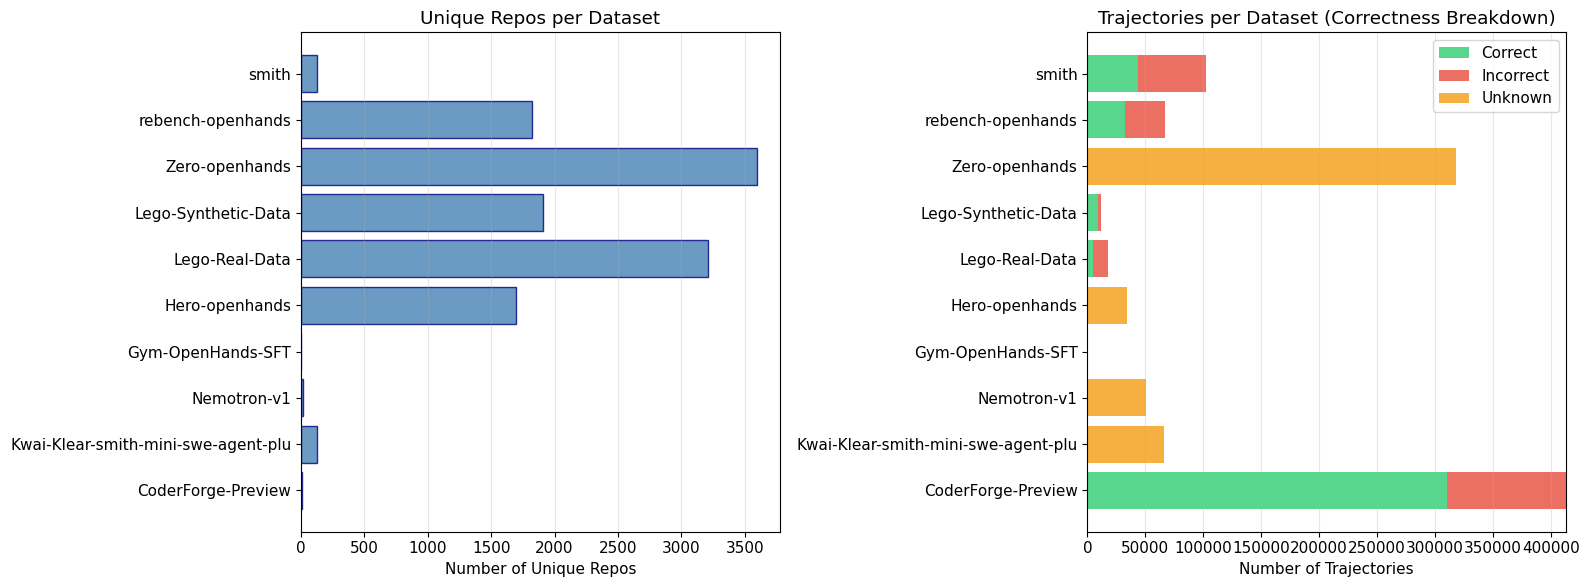

In [6]:
# Visualize: repos per dataset and correctness breakdown
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ds_names = [r['Dataset'] for r in dataset_summary_rows]
ds_short = [n.replace('SWE-', '').replace('-trajectories', '').replace('-Trajectories', '')[:35] for n in ds_names]

# Left: number of repos
axes[0].barh(ds_short, [r['#Repos'] for r in dataset_summary_rows], color='steelblue', edgecolor='navy', alpha=0.8)
axes[0].set_xlabel('Number of Unique Repos')
axes[0].set_title('Unique Repos per Dataset')
axes[0].grid(axis='x', alpha=0.3)

# Right: stacked bar for correct/incorrect/unknown
correct_vals = [r['#Correct'] for r in dataset_summary_rows]
incorrect_vals = [r['#Incorrect'] for r in dataset_summary_rows]
unknown_vals = [r['#Unknown'] for r in dataset_summary_rows]

axes[1].barh(ds_short, correct_vals, color='#2ecc71', label='Correct', alpha=0.8)
axes[1].barh(ds_short, incorrect_vals, left=correct_vals, color='#e74c3c', label='Incorrect', alpha=0.8)
left2 = [c + i for c, i in zip(correct_vals, incorrect_vals)]
axes[1].barh(ds_short, unknown_vals, left=left2, color='#f39c12', label='Unknown', alpha=0.8)
axes[1].set_xlabel('Number of Trajectories')
axes[1].set_title('Trajectories per Dataset (Correctness Breakdown)')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Detailed per-repo breakdown for each dataset (top 15 repos per dataset)
for ds in sorted(dataset_repo_stats.keys()):
    repos = dataset_repo_stats[ds]
    print(f'\n{"=" * 100}')
    print(f'Dataset: {ds} ({len(repos)} repos)')
    print(f'{"=" * 100}')
    print(f'{"Repo":<55} {"Total":>6} {"Correct":>8} {"Incorrect":>10} {"Unknown":>8}')
    print('-' * 100)
    
    sorted_repos = sorted(repos.items(), key=lambda x: sum(x[1].values()), reverse=True)
    for repo, counts in sorted_repos[:15]:
        total = sum(counts.values())
        correct = counts.get('correct', 0)
        incorrect = counts.get('incorrect', 0)
        unknown = total - correct - incorrect
        repo_display = str(repo)[:53]
        print(f'{repo_display:<55} {total:>6} {correct:>8} {incorrect:>10} {unknown:>8}')
    
    if len(sorted_repos) > 15:
        print(f'  ... and {len(sorted_repos) - 15} more repos')


Dataset: CoderForge-Preview (10 repos)
Repo                                                     Total  Correct  Incorrect  Unknown
----------------------------------------------------------------------------------------------------
unknown                                                 359630   268480      91150        0
pandas                                                   18615    14174       4441        0
numpy                                                    10223     7950       2273        0
pillow                                                    8512     7104       1408        0
aiohttp                                                   4062     3340        722        0
tornado                                                   3183     2190        993        0
scrapy                                                    2883     2326        557        0
pyramid                                                   2533     2042        491        0
datalad                        

## 4. Token Length Distribution

Compute token length statistics:
- Per dataset: total, system, user, assistant
- Per repo: total, system, user, assistant

In [8]:
# Build token length data structures
# Per sample: sum of tokens by role
dataset_token_stats = defaultdict(lambda: {'total': [], 'system': [], 'user': [], 'assistant': []})
repo_token_stats = defaultdict(lambda: {'total': [], 'system': [], 'user': [], 'assistant': []})

for sample in all_data:
    ds = sample['source_dataset']
    repo = sample['repo']
    msg_info = sample['msg_token_info']
    
    total_tokens = 0
    system_tokens = 0
    user_tokens = 0
    assistant_tokens = 0
    
    for role, tc in msg_info:
        total_tokens += tc
        if role == 'system':
            system_tokens += tc
        elif role == 'user':
            user_tokens += tc
        elif role == 'assistant':
            assistant_tokens += tc
    
    dataset_token_stats[ds]['total'].append(total_tokens)
    dataset_token_stats[ds]['system'].append(system_tokens)
    dataset_token_stats[ds]['user'].append(user_tokens)
    dataset_token_stats[ds]['assistant'].append(assistant_tokens)
    
    repo_token_stats[repo]['total'].append(total_tokens)
    repo_token_stats[repo]['system'].append(system_tokens)
    repo_token_stats[repo]['user'].append(user_tokens)
    repo_token_stats[repo]['assistant'].append(assistant_tokens)

print(f'Token stats computed for {len(dataset_token_stats)} datasets and {len(repo_token_stats)} repos.')

Token stats computed for 10 datasets and 5916 repos.


### 4.1 Per-Dataset Token Length Summary Table

In [9]:
def compute_stats(values):
    """Compute mean, min, max for a list of values."""
    if not values:
        return 0, 0, 0
    return int(np.mean(values)), int(np.min(values)), int(np.max(values))

# Build DataFrame
rows = []
for ds in sorted(dataset_token_stats.keys()):
    stats = dataset_token_stats[ds]
    n = len(stats['total'])
    total_mean, total_min, total_max = compute_stats(stats['total'])
    sys_mean, sys_min, sys_max = compute_stats(stats['system'])
    user_mean, user_min, user_max = compute_stats(stats['user'])
    asst_mean, asst_min, asst_max = compute_stats(stats['assistant'])
    rows.append({
        'Dataset': ds, 'N': n,
        'Total_Mean': total_mean, 'Total_Min': total_min, 'Total_Max': total_max,
        'System_Mean': sys_mean, 'System_Min': sys_min, 'System_Max': sys_max,
        'User_Mean': user_mean, 'User_Min': user_min, 'User_Max': user_max,
        'Assistant_Mean': asst_mean, 'Assistant_Min': asst_min, 'Assistant_Max': asst_max,
    })

df_dataset = pd.DataFrame(rows)

print('Token Length Distribution per Dataset (tokens per sample)')
print('=' * 140)
print(f'{"Dataset":<42} {"N":>6} | {"Total":^21} | {"System":^21} | {"User":^21} | {"Assistant":^21}')
print(f'{"":<42} {"":>6} | {"Mean":>6} {"Min":>6} {"Max":>7} | {"Mean":>6} {"Min":>6} {"Max":>7} | {"Mean":>6} {"Min":>6} {"Max":>7} | {"Mean":>6} {"Min":>6} {"Max":>7}')
print('-' * 140)
for _, row in df_dataset.iterrows():
    ds_name = row['Dataset'][:40]
    print(f'{ds_name:<42} {row["N"]:>6} | '
          f'{row["Total_Mean"]:>6,} {row["Total_Min"]:>6,} {row["Total_Max"]:>7,} | '
          f'{row["System_Mean"]:>6,} {row["System_Min"]:>6,} {row["System_Max"]:>7,} | '
          f'{row["User_Mean"]:>6,} {row["User_Min"]:>6,} {row["User_Max"]:>7,} | '
          f'{row["Assistant_Mean"]:>6,} {row["Assistant_Min"]:>6,} {row["Assistant_Max"]:>7,}')
print('=' * 140)

Token Length Distribution per Dataset (tokens per sample)
Dataset                                         N |         Total         |        System         |         User          |       Assistant      
                                                  |   Mean    Min     Max |   Mean    Min     Max |   Mean    Min     Max |   Mean    Min     Max
--------------------------------------------------------------------------------------------------------------------------------------------
CoderForge-Preview                         413278 | 33,880  2,256 199,545 |  1,236  1,236   1,236 |  1,196    888  29,582 |  2,058     35  88,346
Kwai-Klear-SWE-smith-mini-swe-agent-plus    65994 | 18,991  3,413 128,738 |    112    112     112 | 12,306  2,215  91,348 |  6,572    678 108,710
Nemotron-SWE-v1                             51029 | 36,437 11,467 241,369 |  1,694  1,694   1,694 |  1,398    952  20,264 |  2,393    445  16,830
SWE-Gym-OpenHands-SFT-Trajectories            491 | 18,846  2,581  84,9

In [10]:
# Display as styled pandas DataFrame
display_df = df_dataset.set_index('Dataset')
display_df.columns = pd.MultiIndex.from_tuples([
    ('Count', 'N'),
    ('Total', 'Mean'), ('Total', 'Min'), ('Total', 'Max'),
    ('System', 'Mean'), ('System', 'Min'), ('System', 'Max'),
    ('User', 'Mean'), ('User', 'Min'), ('User', 'Max'),
    ('Assistant', 'Mean'), ('Assistant', 'Min'), ('Assistant', 'Max'),
])
display_df

Count  Total         \
                                                         N   Mean    Min   
Dataset                                                                    
CoderForge-Preview                                  413278  33880   2256   
Kwai-Klear-SWE-smith-mini-swe-agent-plus-trajec...   65994  18991   3413   
Nemotron-SWE-v1                                      51029  36437  11467   
SWE-Gym-OpenHands-SFT-Trajectories                     491  18846   2581   
SWE-Hero-openhands-trajectories                      34269  37182  10009   
SWE-Lego-Real-Data                                   18036  54452  14588   
SWE-Lego-Synthetic-Data                              11471  42575  16757   
SWE-Zero-openhands-trajectories                     318115  24493   3908   
SWE-rebench-openhands-trajectories                   67074  40081   9908   
SWE-smith-trajectories                              102078  28726   1161   

                                                           System              \
                                                       Max   Mean   Min   Max   
Dataset                                                                         
CoderForge-Preview                                  199545   1236  1236  1236   
Kwai-Klear-SWE-smith-mini-swe-agent-plus-trajec...  128738    112   112   112   
Nemotron-SWE-v1                                     241369   1694  1694  1694   
SWE-Gym-OpenHands-SFT-Trajectories                   84985   1130  1130  1130   
SWE-Hero-openhands-trajectories                     241369   1694  1694  1694   
SWE-Lego-Real-Data                                  238586   3851  3851  3851   
SWE-Lego-Synthetic-Data                             283477   3851  3851  3851   
SWE-Zero-openhands-trajectories                     230025   1374  1374  1374   
SWE-rebench-openhands-trajectories                  119920   2423  2423  2423   
SWE-smith-trajectories                              251818    625    15   944   

                                                     User                \
                                                     Mean   Min     Max   
Dataset                                                                   
CoderForge-Preview                                   1196   888   29582   
Kwai-Klear-SWE-smith-mini-swe-agent-plus-trajec...  12306  2215   91348   
Nemotron-SWE-v1                                      1398   952   20264   
SWE-Gym-OpenHands-SFT-Trajectories                  14987  1082   77233   
SWE-Hero-openhands-trajectories                      1409   949   20264   
SWE-Lego-Real-Data                                  35988  6744  211312   
SWE-Lego-Synthetic-Data                             26576  7251  267626   
SWE-Zero-openhands-trajectories                      1238   724  137113   
SWE-rebench-openhands-trajectories                   1407   949   17160   
SWE-smith-trajectories                              20759   281  246123   

                                                   Assistant                
                                                        Mean   Min     Max  
Dataset                                                                     
CoderForge-Preview                                      2058    35   88346  
Kwai-Klear-SWE-smith-mini-swe-agent-plus-trajec...      6572   678  108710  
Nemotron-SWE-v1                                         2393   445   16830  
SWE-Gym-OpenHands-SFT-Trajectories                      2729   369   15654  
SWE-Hero-openhands-trajectories                         2408   422   16660  
SWE-Lego-Real-Data                                     14612  1721   80365  
SWE-Lego-Synthetic-Data                                12148  4262   98098  
SWE-Zero-openhands-trajectories                         2097   184   36138  
SWE-rebench-openhands-trajectories                      2665   328   26366  
SWE-smith-trajectories                                  5397     0   68409

### 4.2 Per-Dataset Token Length Distribution (Visualization)

/tmp/ipykernel_3863357/4131872818.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, vert=False, labels=short_names, patch_artist=True, showfliers=False, whis=[5, 95])


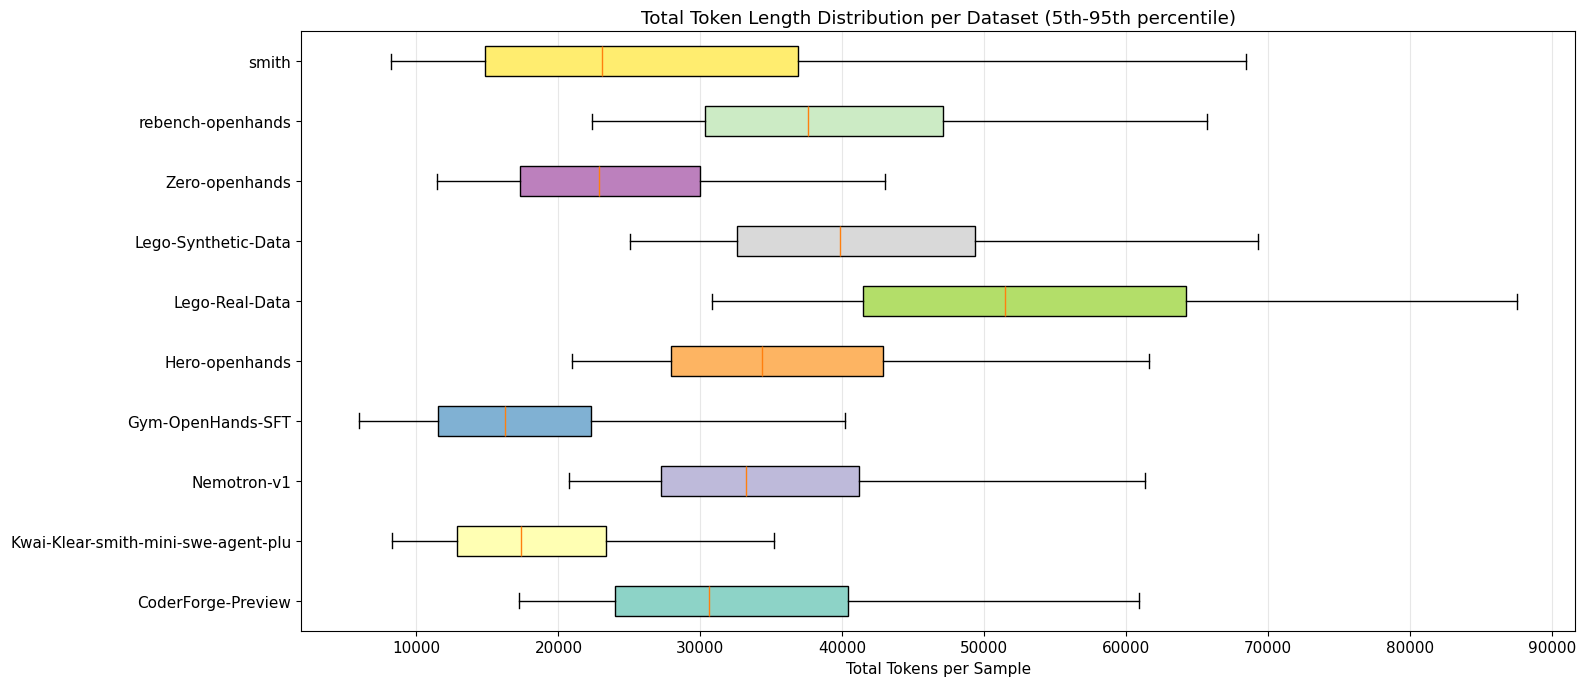

In [11]:
# Box plot: total token length per dataset
fig, ax = plt.subplots(figsize=(16, 7))
datasets_sorted = sorted(dataset_token_stats.keys())
data_to_plot = [dataset_token_stats[ds]['total'] for ds in datasets_sorted]
short_names = [ds.replace('SWE-', '').replace('-trajectories', '').replace('-Trajectories', '')[:35] for ds in datasets_sorted]

bp = ax.boxplot(data_to_plot, vert=False, labels=short_names, patch_artist=True, showfliers=False, whis=[5, 95])
colors_bp = plt.cm.Set3(np.linspace(0, 1, len(datasets_sorted)))
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
ax.set_xlabel('Total Tokens per Sample')
ax.set_title('Total Token Length Distribution per Dataset (5th-95th percentile)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

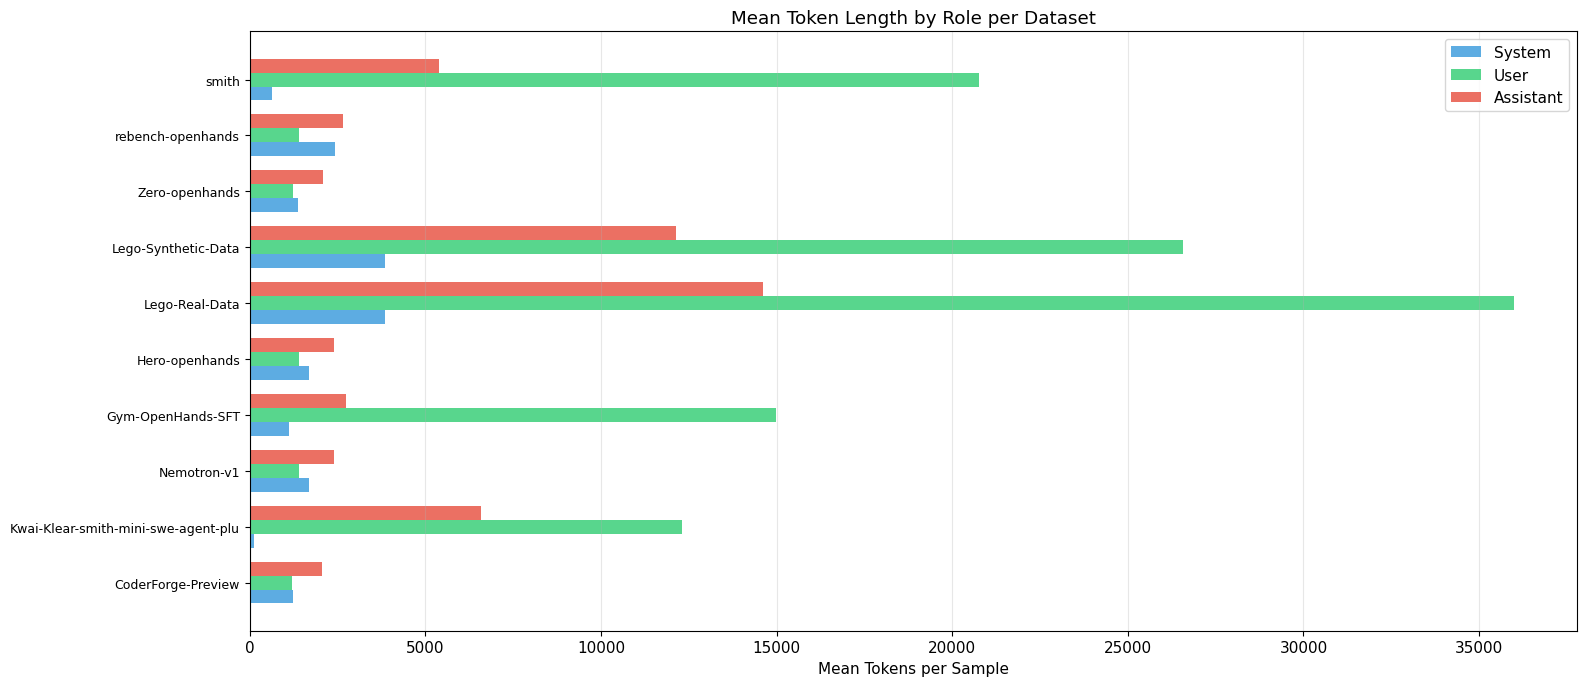

In [12]:
# Per-role mean token distribution (grouped bar chart)
fig, ax = plt.subplots(figsize=(16, 7))
x = np.arange(len(datasets_sorted))
width = 0.25

sys_means = [np.mean(dataset_token_stats[ds]['system']) for ds in datasets_sorted]
user_means = [np.mean(dataset_token_stats[ds]['user']) for ds in datasets_sorted]
asst_means = [np.mean(dataset_token_stats[ds]['assistant']) for ds in datasets_sorted]

ax.barh(x - width, sys_means, height=width, label='System', color='#3498db', alpha=0.8)
ax.barh(x, user_means, height=width, label='User', color='#2ecc71', alpha=0.8)
ax.barh(x + width, asst_means, height=width, label='Assistant', color='#e74c3c', alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(short_names, fontsize=9)
ax.set_xlabel('Mean Tokens per Sample')
ax.set_title('Mean Token Length by Role per Dataset')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

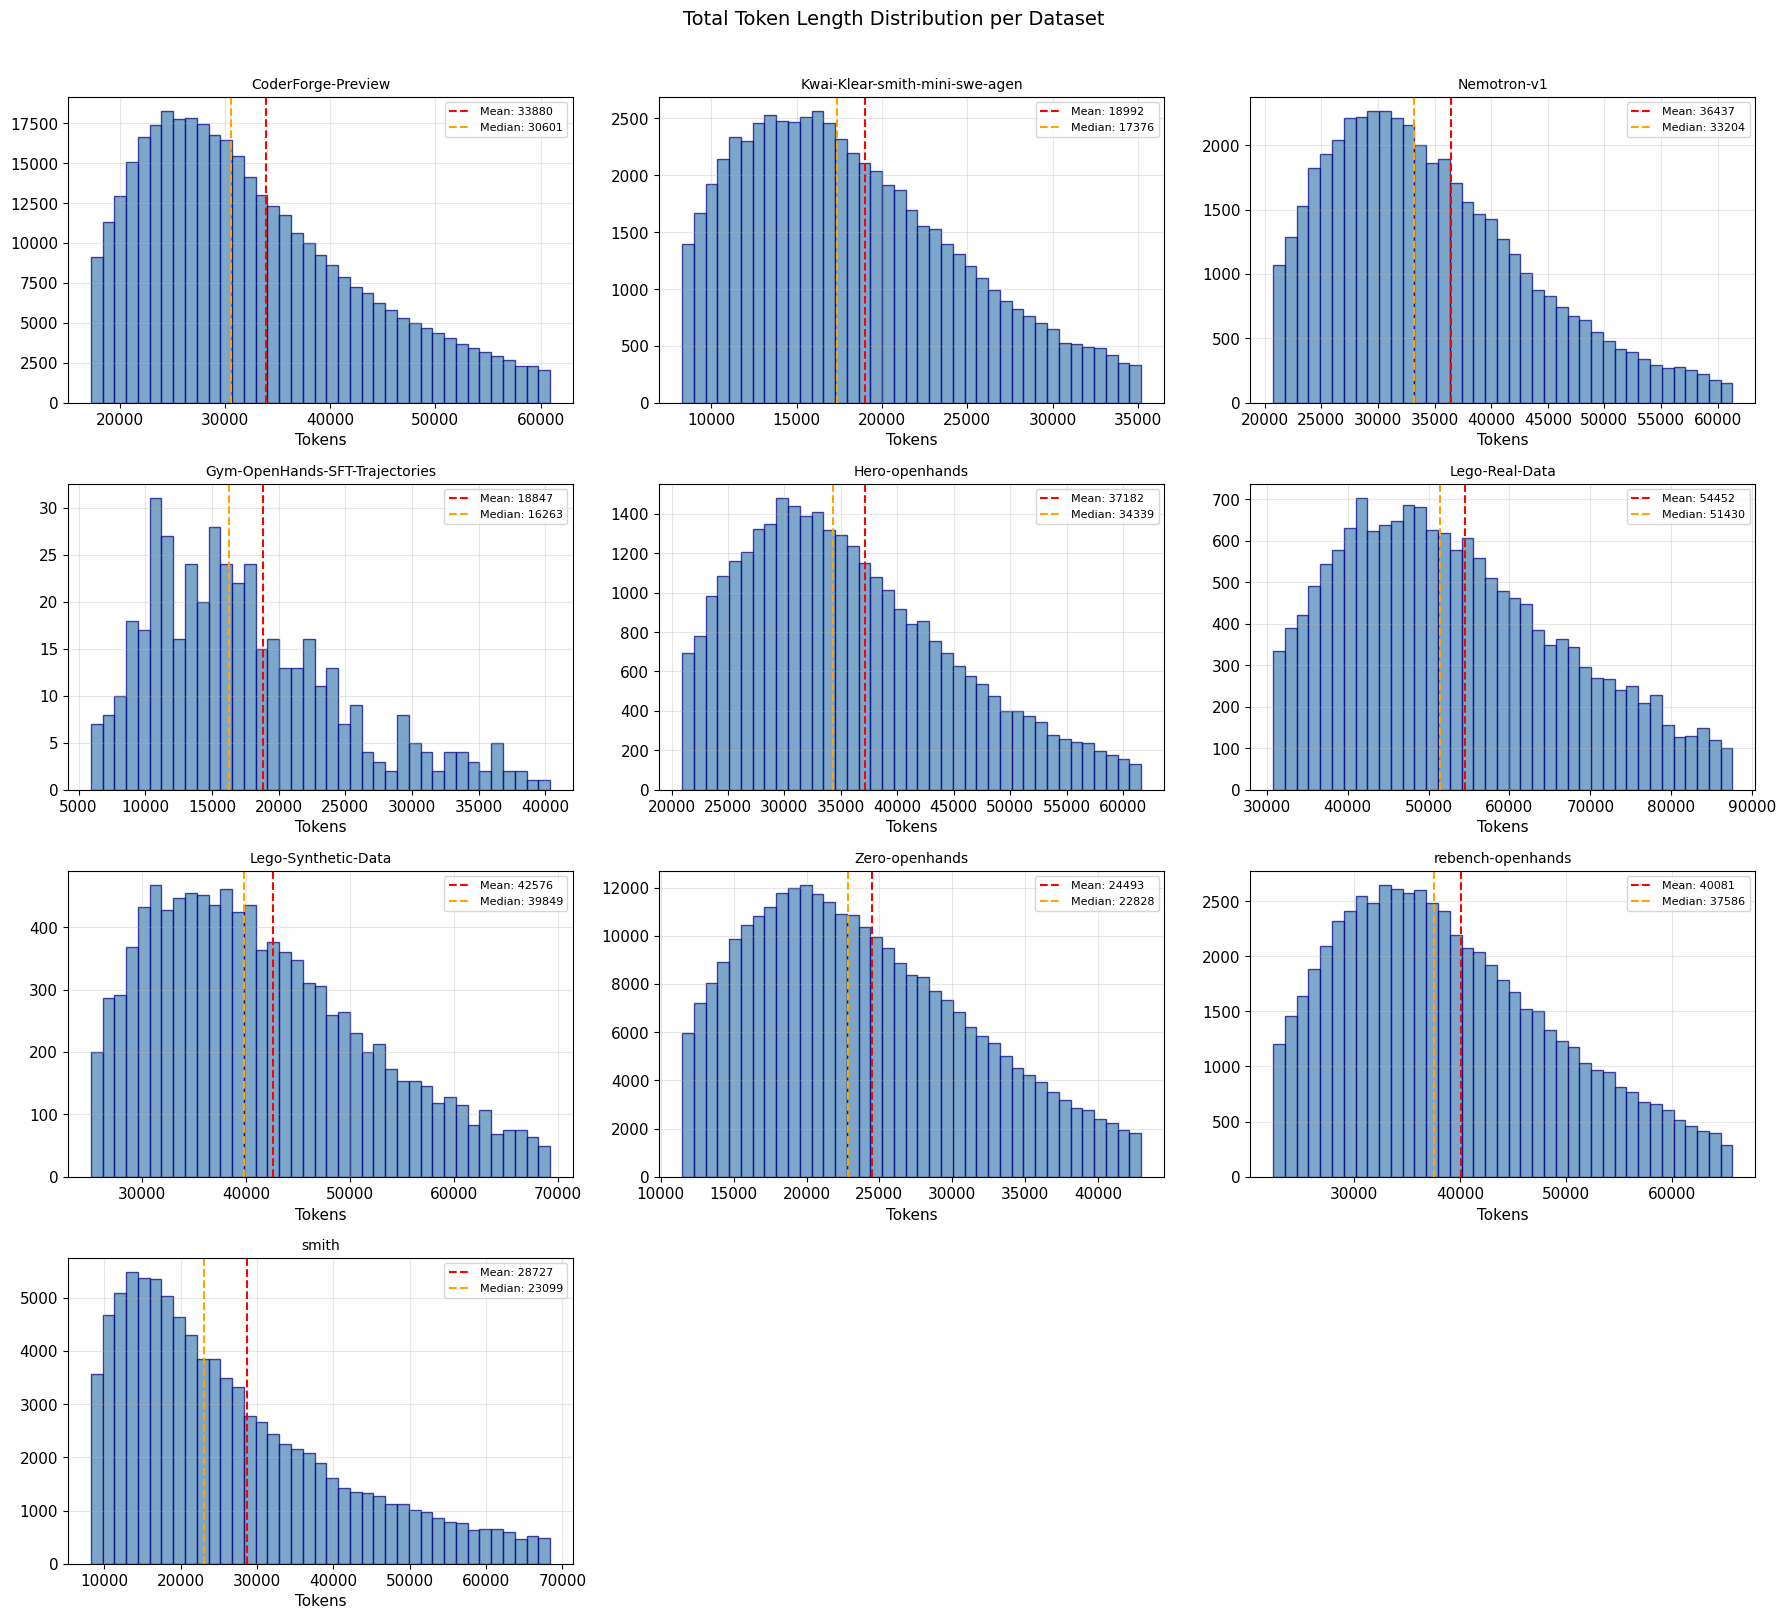

In [13]:
# Histogram: total token distribution per dataset (subplots)
n_datasets = len(datasets_sorted)
n_cols = 3
n_rows = (n_datasets + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes_flat = axes.flatten() if n_datasets > 1 else [axes]

for idx, ds in enumerate(datasets_sorted):
    ax = axes_flat[idx]
    tokens = dataset_token_stats[ds]['total']
    p5, p95 = np.percentile(tokens, [5, 95])
    bins = np.linspace(p5, p95, 40)
    ax.hist(tokens, bins=bins, color='steelblue', edgecolor='navy', alpha=0.7)
    ax.axvline(np.mean(tokens), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {np.mean(tokens):.0f}')
    ax.axvline(np.median(tokens), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {np.median(tokens):.0f}')
    ax.set_title(ds.replace('SWE-', '').replace('-trajectories', '')[:30], fontsize=10)
    ax.set_xlabel('Tokens')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for idx in range(n_datasets, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle('Total Token Length Distribution per Dataset', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 4.3 Per-Repo Token Length Summary Table

In [14]:
# Per-repo token length summary (top 30 repos by sample count)
TOP_N_REPOS = 30
repos_by_count = sorted(repo_token_stats.items(), key=lambda x: len(x[1]['total']), reverse=True)

repo_rows = []
for repo, stats in repos_by_count[:TOP_N_REPOS]:
    n = len(stats['total'])
    total_mean, total_min, total_max = compute_stats(stats['total'])
    sys_mean, sys_min, sys_max = compute_stats(stats['system'])
    user_mean, user_min, user_max = compute_stats(stats['user'])
    asst_mean, asst_min, asst_max = compute_stats(stats['assistant'])
    repo_rows.append({
        'Repo': repo, 'N': n,
        'Total_Mean': total_mean, 'Total_Min': total_min, 'Total_Max': total_max,
        'System_Mean': sys_mean, 'System_Min': sys_min, 'System_Max': sys_max,
        'User_Mean': user_mean, 'User_Min': user_min, 'User_Max': user_max,
        'Assistant_Mean': asst_mean, 'Assistant_Min': asst_min, 'Assistant_Max': asst_max,
    })

df_repo = pd.DataFrame(repo_rows)

print(f'Token Length Distribution per Repo (Top {TOP_N_REPOS} repos by sample count)')
print('=' * 150)
print(f'{"Repo":<50} {"N":>6} | {"Total":^21} | {"System":^21} | {"User":^21} | {"Assistant":^21}')
print(f'{"":<50} {"":>6} | {"Mean":>6} {"Min":>6} {"Max":>7} | {"Mean":>6} {"Min":>6} {"Max":>7} | {"Mean":>6} {"Min":>6} {"Max":>7} | {"Mean":>6} {"Min":>6} {"Max":>7}')
print('-' * 150)
for _, row in df_repo.iterrows():
    repo_name = str(row['Repo'])[:48]
    print(f'{repo_name:<50} {row["N"]:>6} | '
          f'{row["Total_Mean"]:>6,} {row["Total_Min"]:>6,} {row["Total_Max"]:>7,} | '
          f'{row["System_Mean"]:>6,} {row["System_Min"]:>6,} {row["System_Max"]:>7,} | '
          f'{row["User_Mean"]:>6,} {row["User_Min"]:>6,} {row["User_Max"]:>7,} | '
          f'{row["Assistant_Mean"]:>6,} {row["Assistant_Min"]:>6,} {row["Assistant_Max"]:>7,}')
print('=' * 150)
print(f'Total unique repos: {len(repo_token_stats)}')

Token Length Distribution per Repo (Top 30 repos by sample count)
Repo                                                    N |         Total         |        System         |         User          |       Assistant      
                                                          |   Mean    Min     Max |   Mean    Min     Max |   Mean    Min     Max |   Mean    Min     Max
------------------------------------------------------------------------------------------------------------------------------------------------------
unknown                                            360121 | 34,035  2,256 184,255 |  1,235  1,130   1,236 |  1,217    888  77,233 |  2,077     35  88,346
pandas-dev/pandas                                   41808 | 29,990  3,065 191,749 |  1,355     15   2,423 |  5,728    286 144,261 |  3,016      0  38,814
pandas                                              18615 | 32,505  7,466 106,258 |  1,236  1,236   1,236 |  1,193  1,048   1,886 |  2,116    220  16,898
getmoto/moto 

In [15]:
# Display as pandas DataFrame
display_repo_df = df_repo.set_index('Repo')
display_repo_df.columns = pd.MultiIndex.from_tuples([
    ('Count', 'N'),
    ('Total', 'Mean'), ('Total', 'Min'), ('Total', 'Max'),
    ('System', 'Mean'), ('System', 'Min'), ('System', 'Max'),
    ('User', 'Mean'), ('User', 'Min'), ('User', 'Max'),
    ('Assistant', 'Mean'), ('Assistant', 'Min'), ('Assistant', 'Max'),
])
display_repo_df

Count  Total                System              \
                             N   Mean    Min     Max   Mean   Min   Max   
Repo                                                                      
unknown                 360121  34035   2256  184255   1235  1130  1236   
pandas-dev/pandas        41808  29990   3065  191749   1355    15  2423   
pandas                   18615  32505   7466  106258   1236  1236  1236   
getmoto/moto             13264  31562   5064  174707   1009    15  1694   
conan-io/conan           12683  29499   1744  127520    786    15  3851   
Project-MONAI/MONAI      12139  29738   2712  180053   1120    15  3851   
numpy/numpy              12000  26563   5009  144152   1585  1374  1694   
iterative/dvc            11420  31626   1818  158490   1100    15  3851   
numpy                    10223  28869   3969  199545   1236  1236  1236   
dask/dask                 8621  26923   2777  194353   1210    15  3851   
pillow                    8512  31774  11210  138708   1236  1236  1236   
tobymao/sqlglot           8503  34930   6066  126775   1591    15  3851   
R2E-Gym/R2E-Gym-Subset    7500  33709  11676  208426   1694  1694  1694   
python/mypy               6812  38953   5859  241369   1341    15  1694   
python-pillow/Pillow      6453  38600  15076  141468   1898  1694  3851   
pydantic/pydantic         6025  33241   3784  163412    741    15  1694   
modin-project/modin       5877  26033   1964  143439   1329    15  3851   
scrapy/scrapy             4841  28017   4332  126815   1385    15  3851   
spyder-ide/spyder         4776  27055   6491   94914   1374  1374  1374   
tornadoweb/tornado        4381  28559   6525  105823   1511    15  3851   
aio-libs/aiohttp          4269  39354   6119  132966   1574  1374  3851   
spack/spack               4269  24447   6153   98671   1374  1374  1374   
Qiskit/qiskit             4091  24875   5966  125841   1374  1374  1374   
mne-tools/mne-python      4081  25187   6561  118534   1414  1374  3851   
aiohttp                   4062  49119  15979  130910   1236  1236  1236   
stanfordnlp/dspy          3921  15635   3795   55077    112   112   112   
bokeh/bokeh               3715  28493   4722  104691   1402  1374  3851   
pygments/pygments         3510  24034   4067  136671    376    15   944   
sunpy/sunpy               3391  25126   5853  140735    834    15  3851   
Transpile-AI/ivy          3291  32730   6775   82916   1374  1374  1374   

                         User               Assistant               
                         Mean   Min     Max      Mean  Min     Max  
Repo                                                                
unknown                  1217   888   77233      2077   35   88346  
pandas-dev/pandas        5728   286  144261      3016    0   38814  
pandas                   1193  1048    1886      2116  220   16898  
getmoto/moto            13479   286  166182      3817    5  108710  
conan-io/conan          14530   287  117435      5759    5   40287  
Project-MONAI/MONAI      7248   286  125946      3351    5   35341  
numpy/numpy              1208   727    3705      2260  304   17236  
iterative/dvc           11413   286  120394      4411   10   68409  
numpy                    1176  1057    1583      1937  150   21830  
dask/dask                8486   286  178527      3958    5   43207  
pillow                   1172  1052    1497      1906  214   31255  
tobymao/sqlglot          9045   442  123061      4795  706   31833  
R2E-Gym/R2E-Gym-Subset   1279  1115    1998      2247  452   12324  
python/mypy              4433   286  126030      3081    5   26974  
python-pillow/Pillow     2267   984  109781      2756  512   39246  
pydantic/pydantic       20633   282  152545      4499    0   46355  
modin-project/modin      3428   281  131014      2777  240   34023  
scrapy/scrapy            5440   286  105496      2559  323   26773  
spyder-ide/spyder        1595   734   74145      2173  311   18612  
tornadoweb/tornado       3081  

### 4.4 Per-Repo Token Length Distribution (Visualization)

/tmp/ipykernel_3863357/1513707464.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, vert=False, labels=repo_labels, patch_artist=True, showfliers=False, whis=[5, 95])


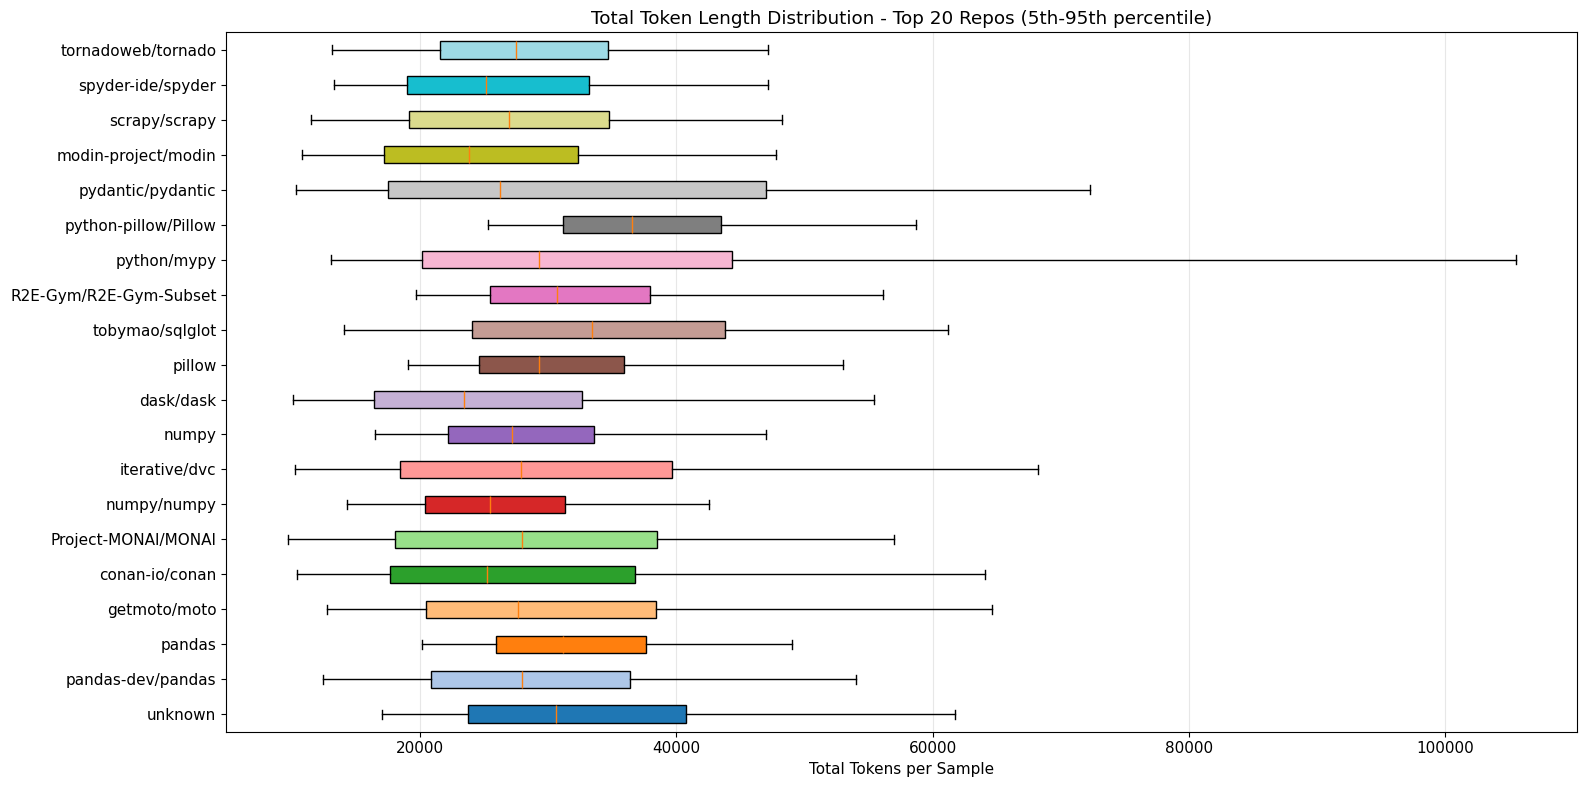

In [16]:
# Box plot: total token length for top 20 repos
TOP_N_VIS = 20
top_repos_vis = [r[0] for r in repos_by_count[:TOP_N_VIS]]

fig, ax = plt.subplots(figsize=(16, 8))
data_to_plot = [repo_token_stats[repo]['total'] for repo in top_repos_vis]
repo_labels = [str(r)[:40] for r in top_repos_vis]

bp = ax.boxplot(data_to_plot, vert=False, labels=repo_labels, patch_artist=True, showfliers=False, whis=[5, 95])
colors_bp = plt.cm.tab20(np.linspace(0, 1, TOP_N_VIS))
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
ax.set_xlabel('Total Tokens per Sample')
ax.set_title(f'Total Token Length Distribution - Top {TOP_N_VIS} Repos (5th-95th percentile)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

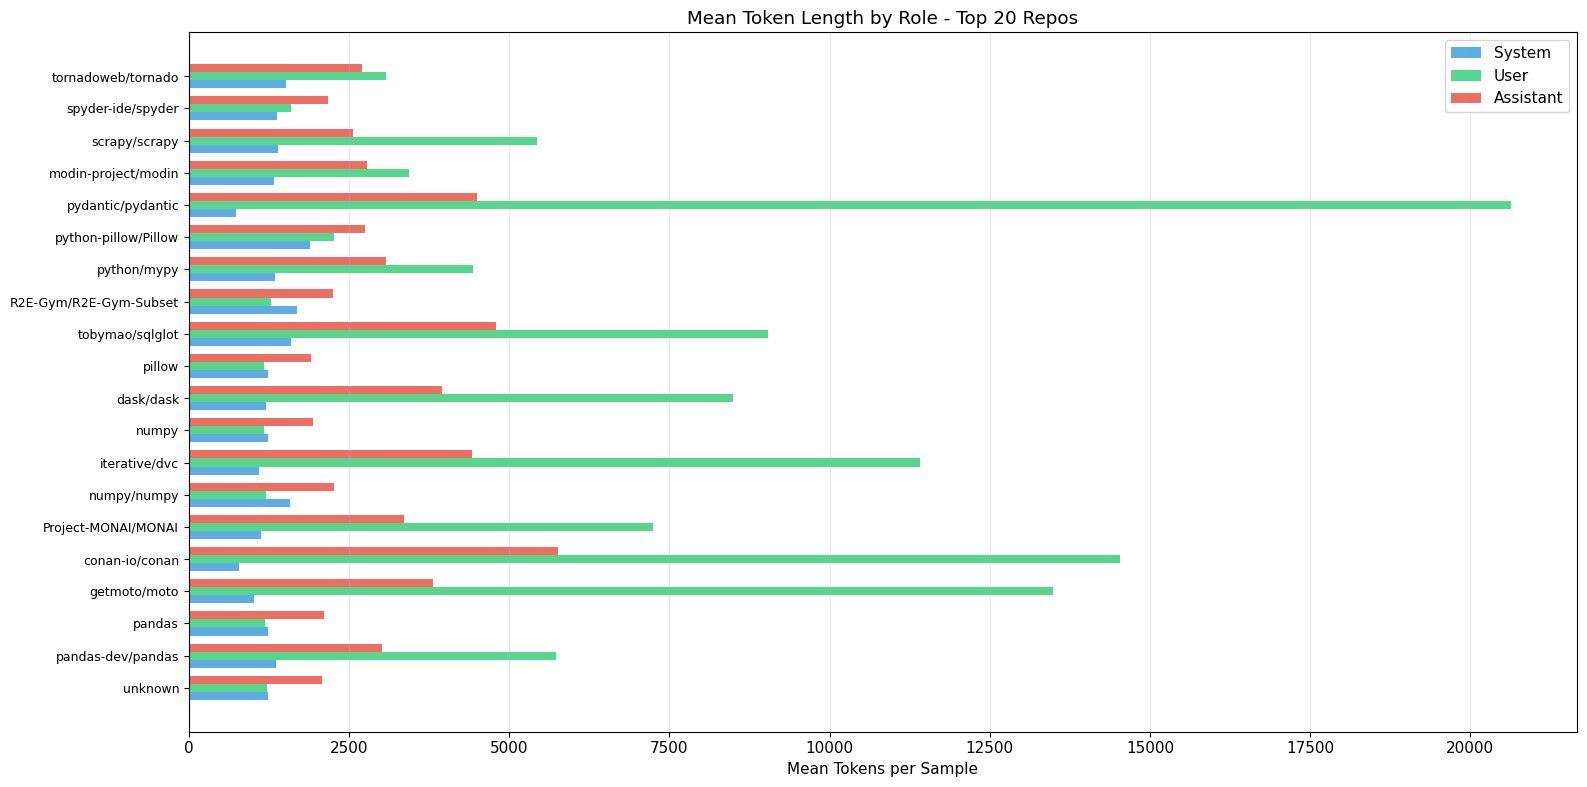

In [17]:
# Per-role breakdown for top repos
fig, ax = plt.subplots(figsize=(16, 8))
x = np.arange(TOP_N_VIS)
width = 0.25

sys_means = [np.mean(repo_token_stats[r]['system']) for r in top_repos_vis]
user_means = [np.mean(repo_token_stats[r]['user']) for r in top_repos_vis]
asst_means = [np.mean(repo_token_stats[r]['assistant']) for r in top_repos_vis]

ax.barh(x - width, sys_means, height=width, label='System', color='#3498db', alpha=0.8)
ax.barh(x, user_means, height=width, label='User', color='#2ecc71', alpha=0.8)
ax.barh(x + width, asst_means, height=width, label='Assistant', color='#e74c3c', alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(repo_labels, fontsize=9)
ax.set_xlabel('Mean Tokens per Sample')
ax.set_title(f'Mean Token Length by Role - Top {TOP_N_VIS} Repos')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.5 Per-Message Token Length Distribution (Individual Messages by Role)

In [18]:
# Analyze individual message token lengths by role
msg_tokens_by_role = defaultdict(list)
msg_tokens_by_dataset_role = defaultdict(lambda: defaultdict(list))
msg_tokens_by_repo_role = defaultdict(lambda: defaultdict(list))

for sample in all_data:
    ds = sample['source_dataset']
    repo = sample['repo']
    for role, tc in sample['msg_token_info']:
        msg_tokens_by_role[role].append(tc)
        msg_tokens_by_dataset_role[ds][role].append(tc)
        msg_tokens_by_repo_role[repo][role].append(tc)

# Overall per-role message length stats
print('Individual Message Token Length Statistics (per message)')
print('=' * 80)
print(f'{"Role":<12} {"Count":>10} {"Mean":>8} {"Median":>8} {"Min":>6} {"Max":>8} {"Std":>8}')
print('-' * 80)
for role in ['system', 'user', 'assistant']:
    vals = msg_tokens_by_role.get(role, [])
    if vals:
        print(f'{role:<12} {len(vals):>10,} {np.mean(vals):>8,.0f} {np.median(vals):>8,.0f} '
              f'{np.min(vals):>6,} {np.max(vals):>8,} {np.std(vals):>8,.0f}')
print('=' * 80)

Individual Message Token Length Statistics (per message)
Role              Count     Mean   Median    Min      Max      Std
--------------------------------------------------------------------------------
system        1,081,835    1,331    1,236     15    3,851      646
user          7,826,696      638      279      7  137,113    1,332
assistant    50,809,350       65       20      0   40,027      154


In [19]:
# Per-dataset, per-role individual message token length table
print('\nIndividual Message Token Length per Dataset per Role')
print('=' * 120)
print(f'{"Dataset":<42} {"Role":<12} {"Count":>8} {"Mean":>8} {"Min":>6} {"Max":>8}')
print('-' * 120)

msg_detail_rows = []
for ds in sorted(msg_tokens_by_dataset_role.keys()):
    for role in ['system', 'user', 'assistant']:
        vals = msg_tokens_by_dataset_role[ds].get(role, [])
        if vals:
            mean_v, min_v, max_v = int(np.mean(vals)), int(np.min(vals)), int(np.max(vals))
            print(f'{ds[:40]:<42} {role:<12} {len(vals):>8,} {mean_v:>8,} {min_v:>6,} {max_v:>8,}')
            msg_detail_rows.append({'Dataset': ds, 'Role': role, 'Count': len(vals), 'Mean': mean_v, 'Min': min_v, 'Max': max_v})

print('=' * 120)

df_msg_detail = pd.DataFrame(msg_detail_rows)
df_msg_detail_pivot = df_msg_detail.pivot_table(index='Dataset', columns='Role', values=['Mean', 'Min', 'Max'], aggfunc='first')
df_msg_detail_pivot


Individual Message Token Length per Dataset per Role
Dataset                                    Role            Count     Mean    Min      Max
------------------------------------------------------------------------------------------------------------------------
CoderForge-Preview                         system        413,278    1,236  1,236    1,236
CoderForge-Preview                         user          413,278    1,196    888   29,582
CoderForge-Preview                         assistant    22,696,854       37      0   22,948
Kwai-Klear-SWE-smith-mini-swe-agent-plus   system         65,994      112    112      112
Kwai-Klear-SWE-smith-mini-swe-agent-plus   user         2,263,693      358     17   80,551
Kwai-Klear-SWE-smith-mini-swe-agent-plus   assistant    2,263,693      191     19   24,192
Nemotron-SWE-v1                            system         51,029    1,694  1,694    1,694
Nemotron-SWE-v1                            user           51,029    1,398    952   20,264
Nemotron-SW

Max                 \
Role                                               assistant system    user   
Dataset                                                                       
CoderForge-Preview                                     22948   1236   29582   
Kwai-Klear-SWE-smith-mini-swe-agent-plus-trajec...     24192    112   80551   
Nemotron-SWE-v1                                         5208   1694   20264   
SWE-Gym-OpenHands-SFT-Trajectories                      2595   1130   12070   
SWE-Hero-openhands-trajectories                         4533   1694   20264   
SWE-Lego-Real-Data                                     17342   3851   52372   
SWE-Lego-Synthetic-Data                                16371   3851   94401   
SWE-Zero-openhands-trajectories                         7925   1374  137113   
SWE-rebench-openhands-trajectories                     10305   2423   17160   
SWE-smith-trajectories                                 40027    944   87715   

                                                        Mean               \
Role                                               assistant system  user   
Dataset                                                                     
CoderForge-Preview                                        37   1236  1196   
Kwai-Klear-SWE-smith-mini-swe-agent-plus-trajec...       191    112   358   
Nemotron-SWE-v1                                           39   1694  1398   
SWE-Gym-OpenHands-SFT-Trajectories                       139   1130   764   
SWE-Hero-openhands-trajectories                           39   1694  1409   
SWE-Lego-Real-Data                                       222   3851   547   
SWE-Lego-Synthetic-Data                                  219   3851   480   
SWE-Zero-openhands-trajectories                           58   1374  1238   
SWE-rebench-openhands-trajectories                        41   2423  1401   
SWE-smith-trajectories                                   176    625   743   

                                                         Min              
Role                                               assistant system user  
Dataset                                                                   
CoderForge-Preview                                         0   1236  888  
Kwai-Klear-SWE-smith-mini-swe-agent-plus-trajec...        19    112   17  
Nemotron-SWE-v1                                            0   1694  952  
SWE-Gym-OpenHands-SFT-Trajectories                         9   1130   18  
SWE-Hero-openhands-trajectories                            0   1694  949  
SWE-Lego-Real-Data                                        19   3851   14  
SWE-Lego-Synthetic-Data                                   19   3851   14  
SWE-Zero-openhands-trajectories                            0   1374  724  
SWE-rebench-openhands-trajectories                         0   2423   21  
SWE-smith-trajectories                                     0     15    7

In [20]:
# Per-repo, per-role individual message token length table (top 30 repos)
print('\nIndividual Message Token Length per Repo per Role (Top 30 repos)')
print('=' * 120)
print(f'{"Repo":<50} {"Role":<12} {"Count":>8} {"Mean":>8} {"Min":>6} {"Max":>8}')
print('-' * 120)

repo_msg_rows = []
top_repo_names = [r[0] for r in repos_by_count[:30]]
for repo in top_repo_names:
    for role in ['system', 'user', 'assistant']:
        vals = msg_tokens_by_repo_role[repo].get(role, [])
        if vals:
            mean_v, min_v, max_v = int(np.mean(vals)), int(np.min(vals)), int(np.max(vals))
            print(f'{str(repo)[:48]:<50} {role:<12} {len(vals):>8,} {mean_v:>8,} {min_v:>6,} {max_v:>8,}')
            repo_msg_rows.append({'Repo': repo, 'Role': role, 'Count': len(vals), 'Mean': mean_v, 'Min': min_v, 'Max': max_v})

print('=' * 120)

df_repo_msg = pd.DataFrame(repo_msg_rows)
df_repo_msg_pivot = df_repo_msg.pivot_table(index='Repo', columns='Role', values=['Mean', 'Min', 'Max'], aggfunc='first')
df_repo_msg_pivot


Individual Message Token Length per Repo per Role (Top 30 repos)
Repo                                               Role            Count     Mean    Min      Max
------------------------------------------------------------------------------------------------------------------------
unknown                                            system        360,121    1,235  1,130    1,236
unknown                                            user          369,260    1,187     18   29,582
unknown                                            assistant    19,606,680       38      0   22,948
pandas-dev/pandas                                  system         41,808    1,355     15    2,423
pandas-dev/pandas                                  user          288,729      829      7   45,348
pandas-dev/pandas                                  assistant    2,145,446       58      0   18,413
pandas                                             system         18,615    1,236  1,236    1,236
pandas                    

Max                    Mean               \
Role                   assistant system   user assistant system  user   
Repo                                                                    
Project-MONAI/MONAI        19739   3851  62907        87   1120   676   
Qiskit/qiskit               6522   1374  23083        61   1374  1216   
R2E-Gym/R2E-Gym-Subset      2455   1694   1998        38   1694  1279   
Transpile-AI/ivy            2649   1374   2371        45   1374   747   
aio-libs/aiohttp            7181   3851  16741        43   1574  1239   
aiohttp                     4423   1236   1565        32   1236  1179   
bokeh/bokeh                 4739   3851  15032        53   1402  1050   
conan-io/conan              6442   3851  41298       148    786   602   
dask/dask                   5952   3851  84717        94   1210   628   
getmoto/moto               14531   1694  36325        90   1009   792   
iterative/dvc              40027   3851  43723       104   1100   650   
mne-tools/mne-python        6468   3851  19686        58   1414  1054   
modin-project/modin         4926   3851  80551        64   1329   761   
numpy                       6300   1236   1583        34   1236  1176   
numpy/numpy                 5415   1694   3705        47   1585  1208   
pandas                      5352   1236   1886        33   1236  1193   
pandas-dev/pandas          18413   2423  45348        58   1355   829   
pillow                     11454   1236   1497        35   1236  1172   
pydantic/pydantic           7203   1694  87715       122    741   855   
pygments/pygments          13183    944  30901       176    376   608   
python-pillow/Pillow        4414   3851  29872        44   1898   817   
python/mypy                 5523   1694  30371        59   1341   859   
scrapy/scrapy               6233   3851  29914        66   1385   806   
spack/spack                 7851   1374  62287        62   1374  2304   
spyder-ide/spyder           5079   1374  74145        58   1374  1595   
stanfordnlp/dspy            8072    112  20228       202    112   333   
sunpy/sunpy                 4620   3851  60031       141    834   619   
tobymao/sqlglot             4821   3851  36758        82   1591   545   
tornadoweb/tornado          8126   3851  26860        53   1511   593   
unknown                    22948   1236  29582        38   1235  1187   

                             Min               
Role                   assistant system  user  
Repo                                           
Project-MONAI/MONAI            0     15     7  
Qiskit/qiskit                  0   1374   739  
R2E-Gym/R2E-Gym-Subset         0   1694  1115  
Transpile-AI/ivy               0   1374   727  
aio-libs/aiohttp               0   1374    14  
aiohttp                        0   1236  1048  
bokeh/bokeh                    0   1374    14  
conan-io/conan                 0     15     7  
dask/dask                      0     15     7  
getmoto/moto                   0     15     7  
iterative/dvc                  0     15     7  
mne-tools/mne-python           0   1374    14  
modin-project/modin            0     15    10  
numpy                          0   1236  1057  
numpy/numpy                    0   1374   727  
pandas                         0   1236  1048  
pandas-dev/pandas              0     15     7  
pillow                         0   1236  1052  
pydantic/pydantic              0     15     7  
pygments/pygments              0     15     7  
python-pillow/Pillow           0   1694    14  
python/mypy                    0     15     7  
scrapy/scrapy                  0     15     9  
spack/spack                    0   1374   732  
spyder-ide/spyder              0   1374   734  
stanfordnlp/dspy              20    112    17  
sunpy/sunpy                    0     15     7  
tobymao/sqlglot                0     15     7  
tornadoweb/tornado             0     15     7  
unknown                        0   1130    18

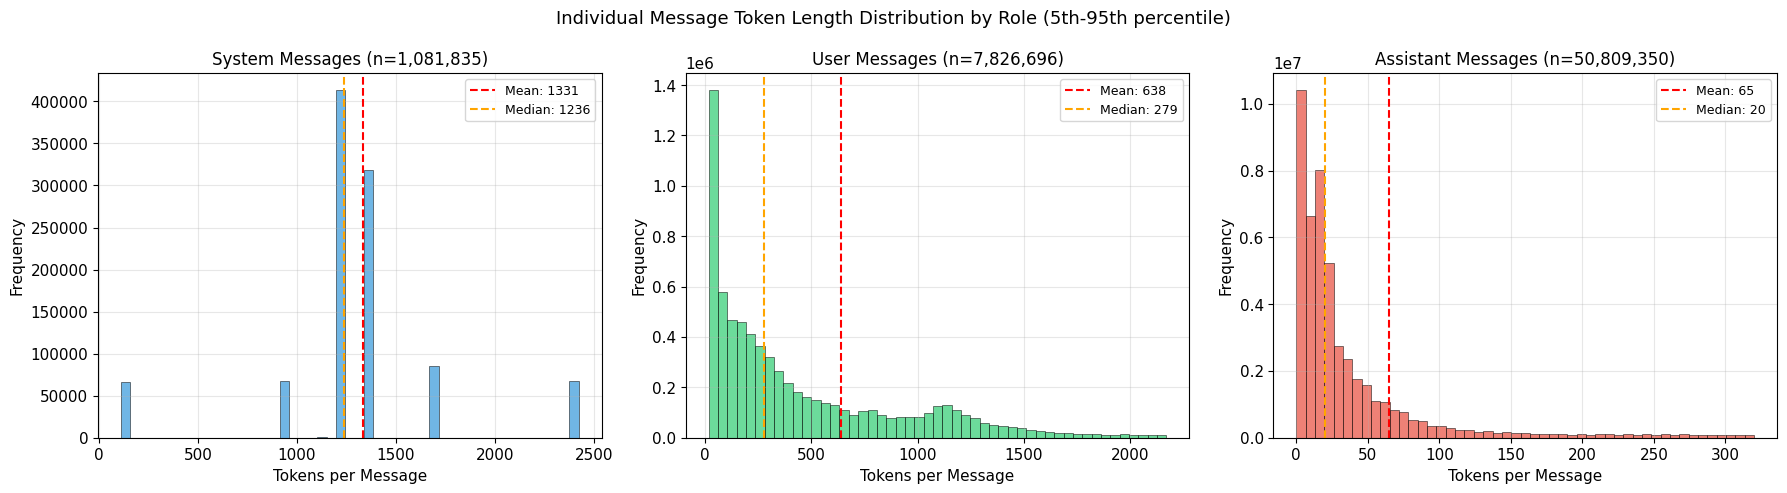

In [21]:
# Histogram: individual message token lengths by role
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
role_colors = {'system': '#3498db', 'user': '#2ecc71', 'assistant': '#e74c3c'}

for idx, role in enumerate(['system', 'user', 'assistant']):
    ax = axes[idx]
    vals = msg_tokens_by_role.get(role, [])
    if vals:
        p5, p95 = np.percentile(vals, [5, 95])
        bins = np.linspace(p5, p95, 50)
        ax.hist(vals, bins=bins, color=role_colors[role], edgecolor='black', alpha=0.7, linewidth=0.5)
        ax.axvline(np.mean(vals), color='red', linestyle='--', label=f'Mean: {np.mean(vals):.0f}')
        ax.axvline(np.median(vals), color='orange', linestyle='--', label=f'Median: {np.median(vals):.0f}')
        ax.set_title(f'{role.capitalize()} Messages (n={len(vals):,})', fontsize=12)
        ax.set_xlabel('Tokens per Message')
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

plt.suptitle('Individual Message Token Length Distribution by Role (5th-95th percentile)', fontsize=13)
plt.tight_layout()
plt.show()

### 4.6 Interactive Repo Lookup

In [22]:
# Change LOOKUP_REPO to look up a specific repo's token stats
LOOKUP_REPO = None  # e.g. 'python__mypy__0.820'

if LOOKUP_REPO and LOOKUP_REPO in repo_token_stats:
    stats = repo_token_stats[LOOKUP_REPO]
    n = len(stats['total'])
    print(f'Token Stats for Repo: {LOOKUP_REPO} (n={n})')
    print('=' * 60)
    print(f'{"Category":<12} {"Mean":>8} {"Min":>8} {"Max":>8}')
    print('-' * 60)
    for cat in ['total', 'system', 'user', 'assistant']:
        vals = stats[cat]
        if vals:
            print(f'{cat:<12} {int(np.mean(vals)):>8,} {int(np.min(vals)):>8,} {int(np.max(vals)):>8,}')
    print('=' * 60)
    
    # Also show per-message stats for this repo
    print(f'\nPer-message stats:')
    print(f'{"Role":<12} {"Count":>8} {"Mean":>8} {"Min":>8} {"Max":>8}')
    print('-' * 60)
    for role in ['system', 'user', 'assistant']:
        vals = msg_tokens_by_repo_role[LOOKUP_REPO].get(role, [])
        if vals:
            print(f'{role:<12} {len(vals):>8,} {int(np.mean(vals)):>8,} {int(np.min(vals)):>8,} {int(np.max(vals)):>8,}')
elif LOOKUP_REPO:
    print(f'Repo "{LOOKUP_REPO}" not found.')
    print(f'Example repos: {[r[0] for r in repos_by_count[:10]]}')
else:
    print('Set LOOKUP_REPO to a repo name to see its token stats.')
    print(f'Example repos (top 10 by sample count):')
    for repo, _ in repos_by_count[:10]:
        print(f'  {repo}')

Set LOOKUP_REPO to a repo name to see its token stats.
Example repos (top 10 by sample count):
  unknown
  pandas-dev/pandas
  pandas
  getmoto/moto
  conan-io/conan
  Project-MONAI/MONAI
  numpy/numpy
  iterative/dvc
  numpy
  dask/dask


## 5. Overall Summary

In [23]:
# Final summary
all_total_tokens = []
for stats in dataset_token_stats.values():
    all_total_tokens.extend(stats['total'])

print('=' * 62)
print('       SHINE_SWE_OPENSOURCE Dataset Summary')
print('=' * 62)
print(f'  Total Datasets:        {len(dataset_token_stats):>10}')
print(f'  Total Unique Repos:    {len(repo_token_stats):>10,}')
print(f'  Total Trajectories:    {len(all_data):>10,}')
print(f'  Total Correct:         {total_correct:>10,}')
print(f'  Total Incorrect:       {total_incorrect:>10,}')
print(f'  Total Unknown:         {total_unknown:>10,}')
print('-' * 62)
print(f'  Token Stats (per sample):')
print(f'    Mean Total Tokens:   {int(np.mean(all_total_tokens)):>10,}')
print(f'    Median Total Tokens: {int(np.median(all_total_tokens)):>10,}')
print(f'    Min Total Tokens:    {int(np.min(all_total_tokens)):>10,}')
print(f'    Max Total Tokens:    {int(np.max(all_total_tokens)):>10,}')
print('=' * 62)

       SHINE_SWE_OPENSOURCE Dataset Summary
  Total Datasets:                10
  Total Unique Repos:         5,916
  Total Trajectories:     1,081,835
  Total Correct:            400,939
  Total Incorrect:          211,489
  Total Unknown:            469,407
--------------------------------------------------------------
  Token Stats (per sample):
    Mean Total Tokens:       30,763
    Median Total Tokens:     27,896
    Min Total Tokens:         1,161
    Max Total Tokens:       283,477
